In [1]:
# Basic
import requests
import numpy as np
import matplotlib.pyplot as plt

# Agent
from langchain_community.document_loaders import PyPDFLoader
from langchain_core import vectorstores
from langchain_community.vectorstores import Chroma
from langchain_ollama import OllamaEmbeddings

# Machine Learning
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE

/var/folders/t3/97hgmq6x6mg3dybs2fbsfcqr0000gn/T/ipykernel_61289/1625546381.py:7: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader
/Users/guane/Documentos/GlogalLogic/AI-course/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [2]:
url = 'https://www.cs.virginia.edu/~evans/greatworks/diffie.pdf'
response = requests.get(url)

with open('public_key_cryptography.pdf', 'wb') as f:
    f.write(response.content)

In [3]:
loader = PyPDFLoader("./public_key_cryptography.pdf")
data = loader.load()

len(data)

18

In [4]:
embeddings = OllamaEmbeddings(model="nomic-embed-text")
vectorstore = Chroma.from_documents(data, embeddings)


In [5]:
texts = [doc.page_content for doc in data]
vectors = embeddings.embed_documents(texts)

In [6]:
X = np.array(vectors)
X.shape

# 18,768 -> 18,2 

(18, 768)

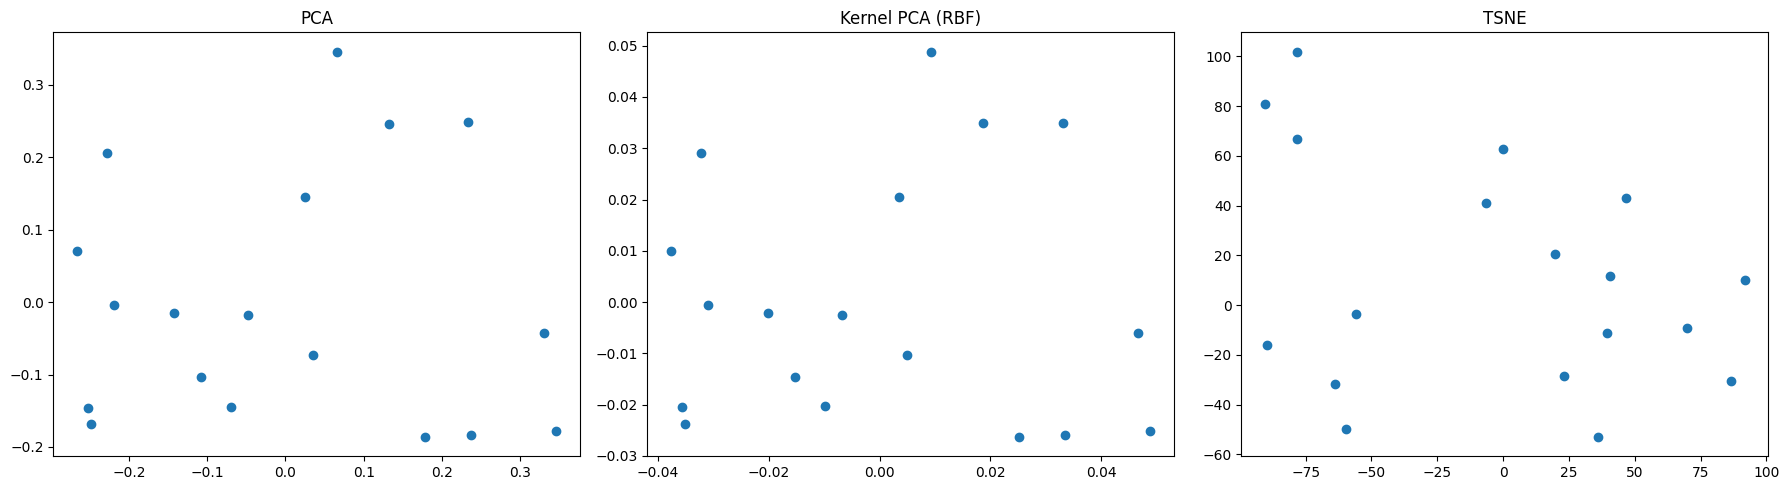

In [7]:
# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Kernel PCA
kpca = KernelPCA(n_components=2, kernel="rbf", gamma=0.01)
X_kpca = kpca.fit_transform(X)

# UMAP (mejor para embeddings)
tsne_model = TSNE(n_components=2, perplexity=5, random_state=42)
X_tsne = tsne_model.fit_transform(X)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(X_pca[:,0], X_pca[:,1])
axes[0].set_title("PCA")
axes[1].scatter(X_kpca[:,0], X_kpca[:,1])
axes[1].set_title("Kernel PCA (RBF)")
axes[2].scatter(X_tsne[:,0], X_tsne[:,1])
axes[2].set_title("TSNE")
plt.tight_layout()
plt.show()